In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report , mean_absolute_error , r2_score
from google.colab import drive
import joblib

In [3]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ML learn by shivam/CSV Files/pizza_v2.csv')
df.head()

Mounted at /content/drive


,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,"Rp235,000",22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,"Rp198,000",20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,"Rp120,000",16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,"Rp155,000",14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,"Rp248,000",18 inch,mozzarella,double_signature,jumbo,yes,no,yes


In [4]:
df.tail()

,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
124,E,"Rp39,000",8.5 inch,tuna,spicy tuna,small,yes,yes,yes
125,E,"Rp72,000",12 inch,tuna,spicy tuna,medium,yes,yes,yes
126,E,"Rp99,000",14 inch,tuna,spicy tuna,large,yes,yes,yes
127,E,"Rp44,000",8.5 inch,meat,BBQ_meat_fiesta,small,yes,no,yes
128,E,"Rp78,000",12 inch,meat,BBQ_meat_fiesta,medium,no,no,yes


In [5]:
df.shape

(129, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          129 non-null    object
 1   price_rupiah     129 non-null    object
 2   diameter         129 non-null    object
 3   topping          129 non-null    object
 4   variant          129 non-null    object
 5   size             129 non-null    object
 6   extra_sauce      129 non-null    object
 7   extra_cheese     129 non-null    object
 8   extra_mushrooms  129 non-null    object
dtypes: object(9)
memory usage: 9.2+ KB


In [7]:
df.isnull().sum()

,0
company,0
price_rupiah,0
diameter,0
topping,0
variant,0
size,0
extra_sauce,0
extra_cheese,0
extra_mushrooms,0


In [8]:
df.head()

,company,price_rupiah,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,"Rp235,000",22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,"Rp198,000",20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,"Rp120,000",16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,"Rp155,000",14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,"Rp248,000",18 inch,mozzarella,double_signature,jumbo,yes,no,yes


In [9]:
df.rename({'price_rupiah':'price'},axis=1 , inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          129 non-null    object
 1   price            129 non-null    object
 2   diameter         129 non-null    object
 3   topping          129 non-null    object
 4   variant          129 non-null    object
 5   size             129 non-null    object
 6   extra_sauce      129 non-null    object
 7   extra_cheese     129 non-null    object
 8   extra_mushrooms  129 non-null    object
dtypes: object(9)
memory usage: 9.2+ KB


In [11]:
df['price'] = df['price'].str.replace('Rp','').str.replace(',','').astype('int32')

In [12]:
# converting the indonesia currency to indian rupee
def convert(value):
  return value*0.0054

In [13]:
df['price'] = df['price'].apply(convert)

In [14]:
df.head()

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,1269.0,22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,1069.2,20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,648.0,16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,837.0,14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,1339.2,18 inch,mozzarella,double_signature,jumbo,yes,no,yes


In [15]:
df['diameter'] = df['diameter'].str.replace("inch","").str.replace(" ","").astype(float)

In [16]:
df.head()

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,1269.0,22.0,chicken,double_signature,jumbo,yes,yes,no
1,A,1069.2,20.0,papperoni,double_signature,jumbo,yes,yes,no
2,A,648.0,16.0,mushrooms,double_signature,reguler,yes,yes,yes
3,A,837.0,14.0,smoked_beef,double_signature,reguler,yes,no,yes
4,A,1339.2,18.0,mozzarella,double_signature,jumbo,yes,no,yes


In [17]:
df.columns

Index(['company', 'price', 'diameter', 'topping', 'variant', 'size',
       'extra_sauce', 'extra_cheese', 'extra_mushrooms'],
      dtype='object')

In [18]:
df['company'].value_counts()

,count
company,
C,30
E,30
A,25
B,24
D,20


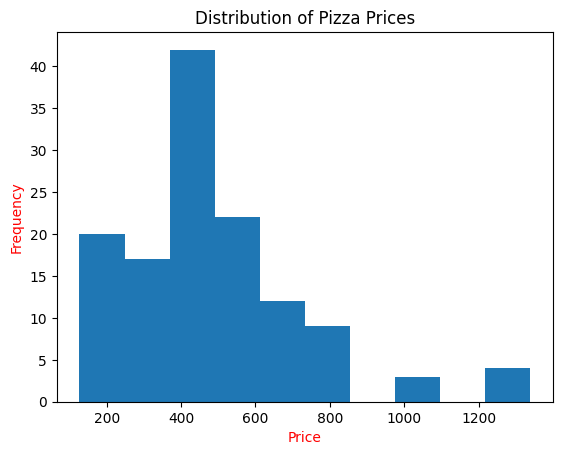

In [19]:
plt.hist(x="price" , data=df)
plt.title("Distribution of Pizza Prices")
plt.xlabel("Price" , color="red")
plt.ylabel("Frequency" , color="red")
plt.show()

<Axes: xlabel='count', ylabel='diameter'>

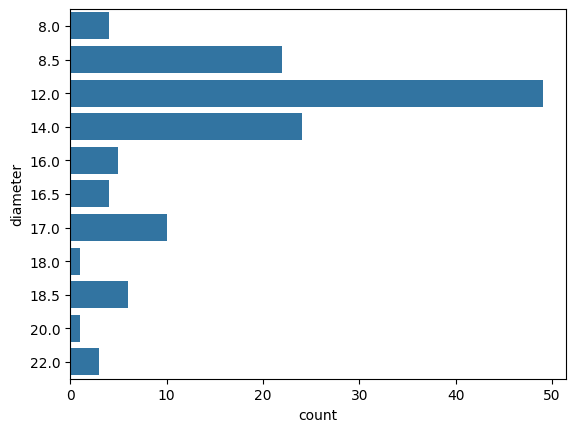

In [20]:
sns.countplot(y='diameter' , data=df)

In [21]:
df['topping'].value_counts()

,count
topping,
chicken,29
mushrooms,22
mozzarella,21
smoked_beef,19
vegetables,9
tuna,9
meat,8
black_papper,3
beef,3


<Axes: xlabel='count', ylabel='topping'>

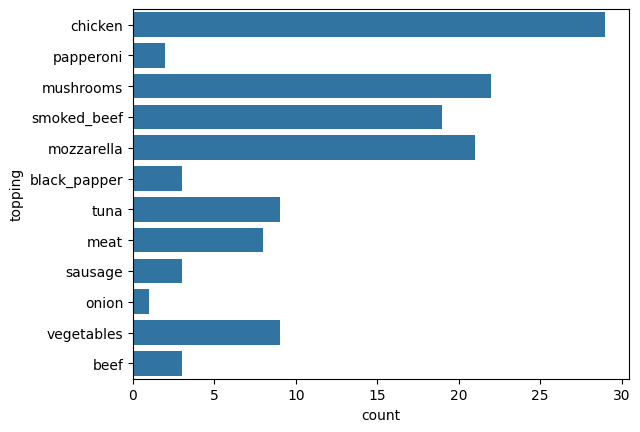

In [22]:
sns.countplot(y='topping' , data=df)

In [23]:
df['variant'].value_counts()

,count
variant,
classic,30
meat_lovers,10
double_mix,10
crunchy,10
new_york,10
double_decker,9
double_signature,5
american_favorite,5
super_supreme,5


<Axes: xlabel='count', ylabel='variant'>

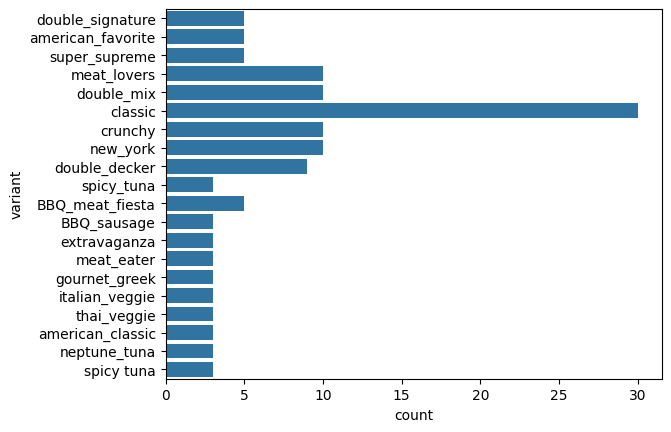

In [24]:
sns.countplot(y='variant' , data=df)

In [25]:
df['size'].value_counts()

,count
size,
medium,41
small,22
large,21
reguler,20
jumbo,15
XL,10


<Axes: xlabel='count', ylabel='size'>

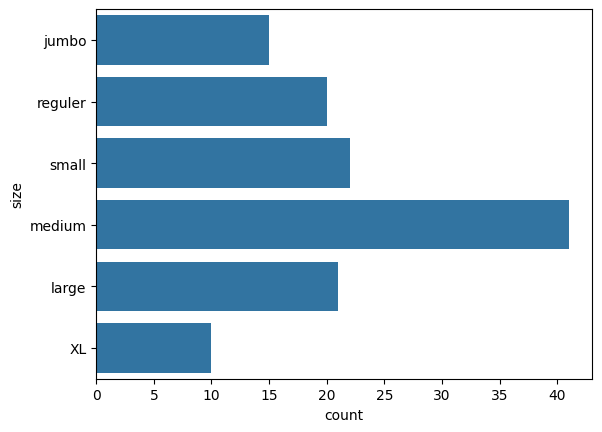

In [26]:
sns.countplot(y='size' , data=df)

<Axes: xlabel='extra_sauce', ylabel='count'>

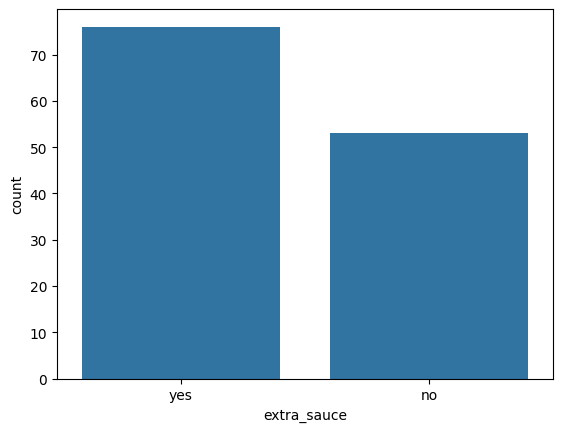

In [27]:
sns.countplot(x='extra_sauce' , data=df)

<Axes: xlabel='extra_mushrooms', ylabel='count'>

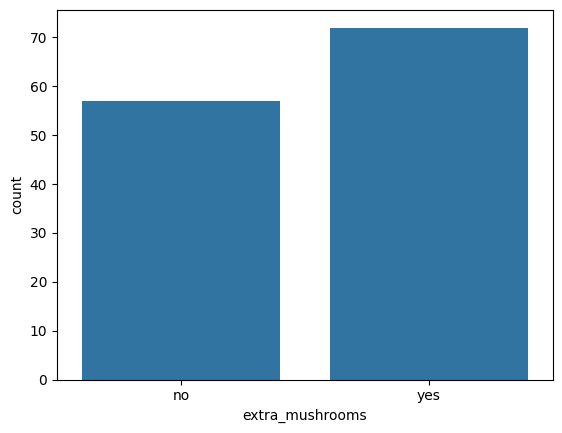

In [28]:
sns.countplot(x='extra_mushrooms' , data=df)

<Axes: xlabel='extra_cheese', ylabel='count'>

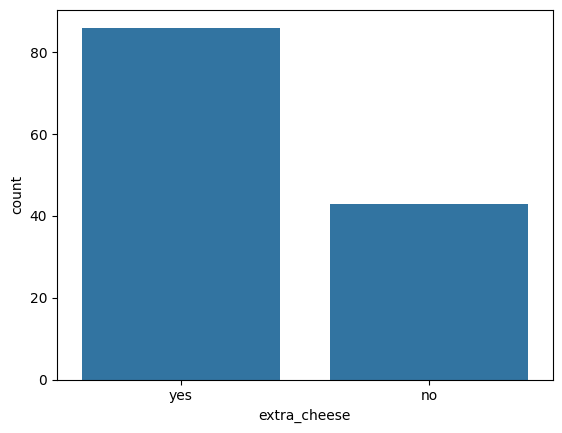

In [29]:
sns.countplot(x='extra_cheese' , data=df)

**Price by Company**






<Axes: xlabel='company', ylabel='price'>

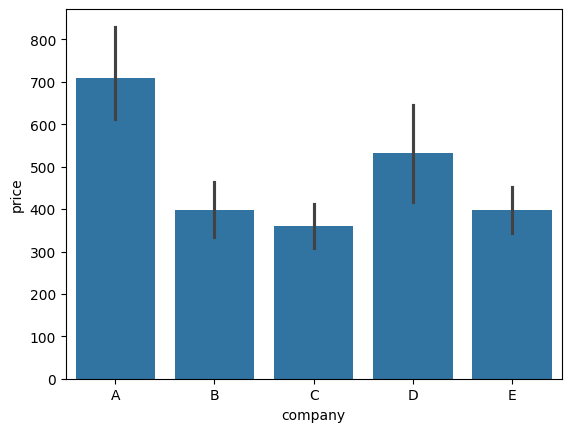

In [30]:
sns.barplot(x='company' , y='price' , data=df)

**Price by Topping**

<Axes: xlabel='price', ylabel='topping'>

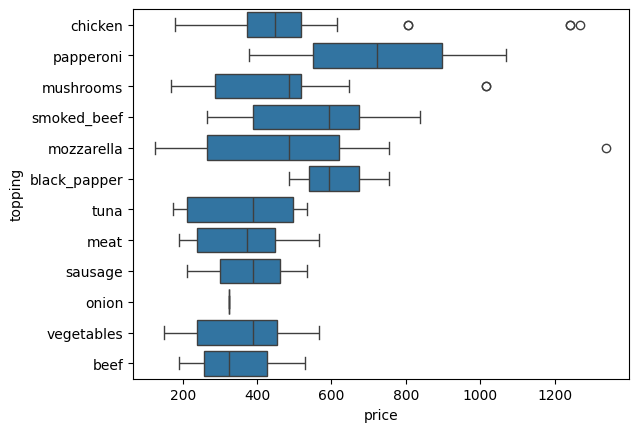

In [31]:
sns.boxplot(y='topping' , x='price' , data=df)

**Price by Size**

<Axes: xlabel='size', ylabel='price'>

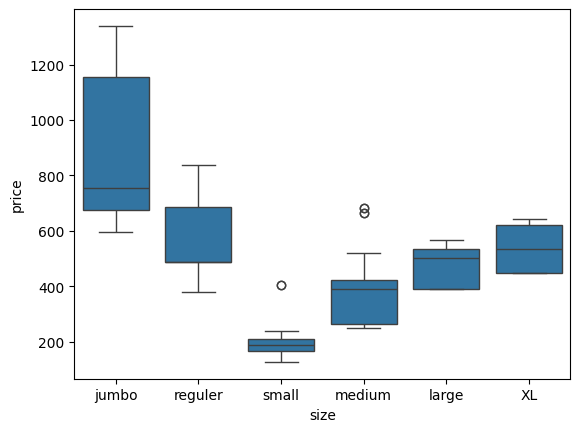

In [32]:
sns.boxplot(x='size' , y='price' , data=df)

**Most Expensive Pizza**

In [33]:
df[df['price'].max()==df['price']]

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
4,A,1339.2,18.0,mozzarella,double_signature,jumbo,yes,no,yes


**Diameter of jumbo size pizza**

In [34]:
df[df['size']=='jumbo']['diameter'].head()

,diameter
0,22.0
1,20.0
4,18.0
5,18.5
6,16.0


**Diameter of XL size pizza**

In [35]:
df[df['size']=='XL']['diameter'].head()

,diameter
29,17.0
35,17.0
41,17.0
47,17.0
93,17.0


**Removing outliers pizza**

In [36]:
df[(df['size']=='jumbo') & (df['diameter'] <= 16)]

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
6,A,594.0,16.0,smoked_beef,american_favorite,jumbo,no,yes,yes
11,A,594.0,16.0,black_papper,super_supreme,jumbo,yes,yes,no
16,A,594.0,16.0,smoked_beef,meat_lovers,jumbo,no,yes,yes
80,D,594.0,16.0,smoked_beef,meat_lovers,jumbo,no,yes,no


In [37]:
df.drop(df.index[[6,11,16,80]])

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,1269.0,22.0,chicken,double_signature,jumbo,yes,yes,no
1,A,1069.2,20.0,papperoni,double_signature,jumbo,yes,yes,no
2,A,648.0,16.0,mushrooms,double_signature,reguler,yes,yes,yes
3,A,837.0,14.0,smoked_beef,double_signature,reguler,yes,no,yes
4,A,1339.2,18.0,mozzarella,double_signature,jumbo,yes,no,yes
...,...,...,...,...,...,...,...,...,...
124,E,210.6,8.5,tuna,spicy tuna,small,yes,yes,yes
125,E,388.8,12.0,tuna,spicy tuna,medium,yes,yes,yes
126,E,534.6,14.0,tuna,spicy tuna,large,yes,yes,yes
127,E,237.6,8.5,meat,BBQ_meat_fiesta,small,yes,no,yes


**Model Building start**


**Label Encoding**

In [38]:
cols = df.select_dtypes(include=['object']).columns
cols

Index(['company', 'topping', 'variant', 'size', 'extra_sauce', 'extra_cheese',
       'extra_mushrooms'],
      dtype='object')

In [39]:
en = LabelEncoder()
for i in cols:
  df[i] = en.fit_transform(df[i])

In [40]:
df.head()

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,0,1269.0,22.0,2,8,1,1,1,0
1,0,1069.2,20.0,7,8,1,1,1,0
2,0,648.0,16.0,5,8,4,1,1,1
3,0,837.0,14.0,9,8,4,1,0,1
4,0,1339.2,18.0,4,8,1,1,0,1


In [41]:
X = df[['company','diameter','topping','variant','size','extra_sauce','extra_cheese','extra_mushrooms']]
y = df['price']

In [42]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)


**Model Training**

In [43]:
lr = LinearRegression()
lr.fit(X_train,y_train)

svm = SVR()
svm.fit(X_train,y_train)

rf = RandomForestRegressor()
rf.fit(X_train,y_train)

gb = GradientBoostingRegressor()
gb.fit(X_train,y_train)

XGB = XGBRegressor()
XGB.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
y_pred1 = lr.predict(X_test)
y_pred2 = svm.predict(X_test)
y_pred3 = rf.predict(X_test)
y_pred4 = gb.predict(X_test)
y_pred5 = XGB.predict(X_test)

**Evaluating Algorithm**

In [45]:
score1 = r2_score(y_test,y_pred1)
score2 = r2_score(y_test,y_pred2)
score3 = r2_score(y_test,y_pred3)
score4 = r2_score(y_test,y_pred4)
score5 = r2_score(y_test,y_pred5)
print(score1 , score2 , score3 , score4 , score5)

0.704967755672546 0.024938741491237093 0.8910040476185147 0.930305371366349 0.7672838488383689


In [46]:
final_data = pd.DataFrame({'Models':['LR','SVR','RF','GB','XGB'] ,
              'R2_SCORE':[score1,score2,score3,score4,score5]})
final_data

,Models,R2_SCORE
0,LR,0.704968
1,SVR,0.024939
2,RF,0.891004
3,GB,0.930305
4,XGB,0.767284


<Axes: xlabel='Models', ylabel='R2_SCORE'>

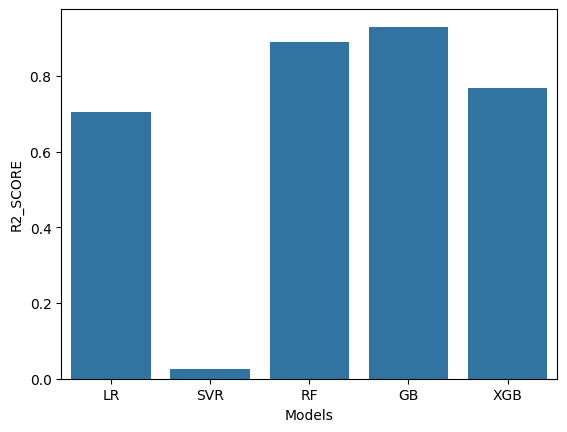

In [47]:
sns.barplot(x='Models' , y='R2_SCORE' , data=final_data)

**Finding best Model by evaluating Feature important given by model**

In [48]:
rf.feature_importances_

array([0.01644404, 0.62463064, 0.03842447, 0.10230309, 0.15642897,
       0.03706016, 0.01493371, 0.00977492])

<Axes: >

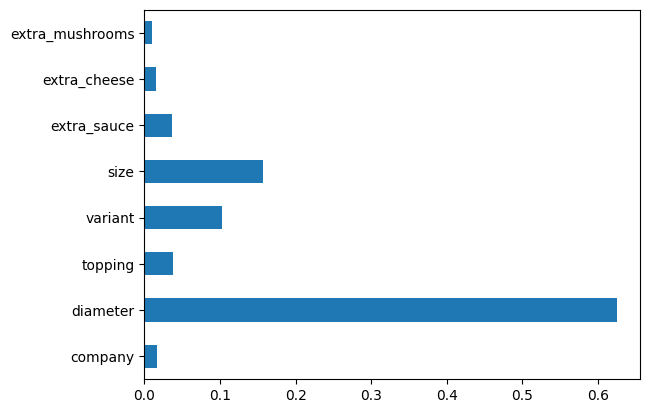

In [49]:
fea = pd.Series(rf.feature_importances_ , index=X.columns)
fea.plot(kind='barh')

In [50]:
gb.feature_importances_

array([0.01337271, 0.67147013, 0.04225226, 0.09406028, 0.12247327,
       0.04531497, 0.00891861, 0.00213777])

<Axes: >

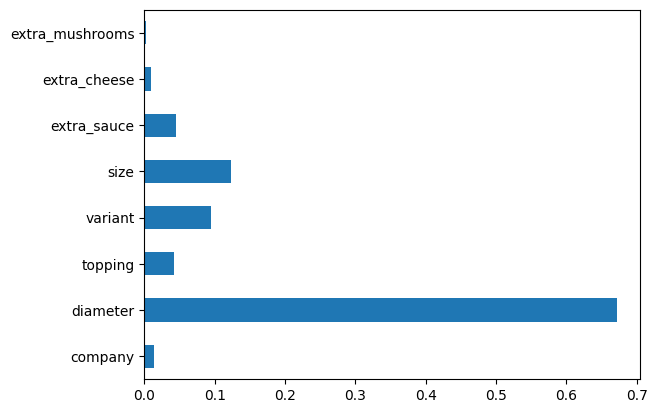

In [51]:
fea = pd.Series(gb.feature_importances_ , index=X.columns)
fea.plot(kind='barh')

In [52]:
XGB.feature_importances_

array([0.0053163 , 0.4393645 , 0.01437583, 0.08024005, 0.35046652,
       0.0910343 , 0.0146667 , 0.00453581], dtype=float32)

<Axes: >

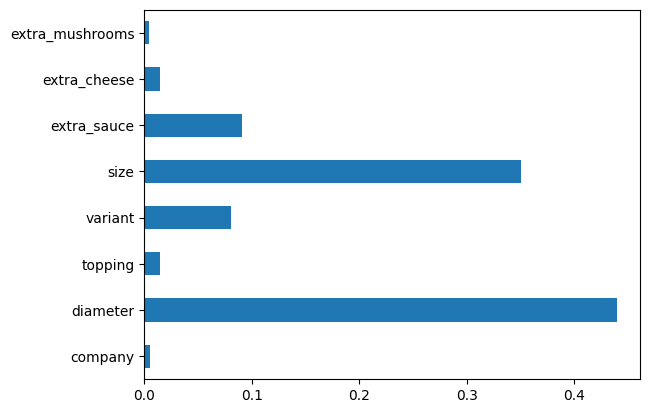

In [53]:
fea = pd.Series(XGB.feature_importances_ , index=X.columns)
fea.plot(kind='barh')

**best model by evaluating is XGB**


In [54]:
X = df[['company','diameter','topping','variant','size','extra_sauce','extra_cheese','extra_mushrooms']]
y = df['price']

In [55]:
pizzaprice_model = XGBRegressor()
pizzaprice_model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
joblib.dump(pizzaprice_model , "pizzaprice_predictionmodel")

['pizzaprice_predictionmodel']

In [57]:
xyz = joblib.load('pizzaprice_predictionmodel')

In [58]:
customer = pd.DataFrame({
    'company':[1],
    'diameter':[16],
    'topping':[1],
    'variant':[1],
    'size':[1],
    'extra_sauce':[1],
    'extra_cheese':[1],
    'extra_mushrooms':[1]
})
customer

,company,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,1,16,1,1,1,1,1,1


In [59]:
xyz.predict(customer)

array([517.1159], dtype=float32)

**PREPARING GUI**

**ENVIRONMENT IS NOT SATISFIED FOR COLAB SO IT CANN'T RUN ON THIS [WE CAN RUN THIS ON VSCODE , PYCHARM ,etc..]**

In [ ]:
from tkinter import *
import pandas as pd

master = Tk()

def show_entry():
    p1=float(e1.get())
    p2=float(e2.get())
    p3=float(e3.get())
    p4=float(e4.get())
    p5=float(e5.get())
    p6=float(e6.get())
    p7=float(e7.get())
    p8=float(e8.get())

    model = joblib.load('pizzaprice_predictionmodel')
    df = pd.DataFrame({
        'company':[p1],
        'diameter':[p2],
        'topping':[p3],
        'variant':[p4],
        'size':[p5],
        'extra_sauce':[p6],
        'extra_cheese':[p7],
        'extra_mushrooms':[p8]
    })
    price = model.predict(df)


    Label(master, text=f"Price: {price[0]}").grid(row=10, column=1)


Label(master, text="Company (encoded):").grid(row=1, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Diameter:").grid(row=2, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Topping (encoded):").grid(row=3, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Variant (encoded):").grid(row=4, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Size (encoded):").grid(row=5, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Extra Sauce (0 or 1):").grid(row=6, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Extra Cheese (0 or 1):").grid(row=7, column=0, padx=10, pady=5, sticky=E)
Label(master, text="Extra Mushrooms (0 or 1):").grid(row=8, column=0, padx=10, pady=5, sticky=E)

e1 = Entry(master)
e2 = Entry(master)
e3 = Entry(master)
e4 = Entry(master)
e5 = Entry(master)
e6 = Entry(master)
e7 = Entry(master)
e8 = Entry(master)

e1.grid(row=1,column=1)
e2.grid(row=2,column=1)
e3.grid(row=3,column=1)
e4.grid(row=4,column=1)
e5.grid(row=5,column=1)
e6.grid(row=6,column=1)
e7.grid(row=7,column=1)
e8.grid(row=8,column=1)


Button(master,text="Predict",command=show_entry).grid(row=9, column=1)

mainloop()